<a href="https://colab.research.google.com/github/kajall120/Data_science_Lab_SE_64/blob/main/BFS%26DFS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Breadth-First Search (BFS) and Depth-First Search (DFS) Implementation

First, let's define a graph using an adjacency list representation. Then, we will implement the BFS and DFS algorithms.

In [1]:
from collections import defaultdict, deque

class Graph:
    def __init__(self):
        self.graph = defaultdict(list)

    def add_edge(self, u, v):
        self.graph[u].append(v)
        # For an undirected graph, add the reverse edge as well
        # self.graph[v].append(u)

    def bfs(self, start_node):
        visited = set()
        queue = deque([start_node])
        traversal_order = []

        visited.add(start_node)

        while queue:
            node = queue.popleft()
            traversal_order.append(node)

            for neighbor in self.graph[node]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append(neighbor)
        return traversal_order

    def dfs(self, start_node):
        visited = set()
        traversal_order = []

        def dfs_recursive(node):
            visited.add(node)
            traversal_order.append(node)

            for neighbor in self.graph[node]:
                if neighbor not in visited:
                    dfs_recursive(neighbor)

        dfs_recursive(start_node)
        return traversal_order

# Create a sample graph
g = Graph()
g.add_edge('A', 'B')
g.add_edge('A', 'C')
g.add_edge('B', 'D')
g.add_edge('B', 'E')
g.add_edge('C', 'F')
g.add_edge('E', 'F')

print("Graph representation:", dict(g.graph))


Graph representation: {'A': ['B', 'C'], 'B': ['D', 'E'], 'C': ['F'], 'E': ['F']}


In [2]:
# Perform BFS starting from node 'A'
bfs_traversal = g.bfs('A')
print("BFS Traversal (starting from A):", bfs_traversal)

BFS Traversal (starting from A): ['A', 'B', 'C', 'D', 'E', 'F']


In [3]:
# Perform DFS starting from node 'A'
dfs_traversal = g.dfs('A')
print("DFS Traversal (starting from A):", dfs_traversal)

DFS Traversal (starting from A): ['A', 'B', 'D', 'E', 'F', 'C']


In [4]:
!pip install networkx matplotlib

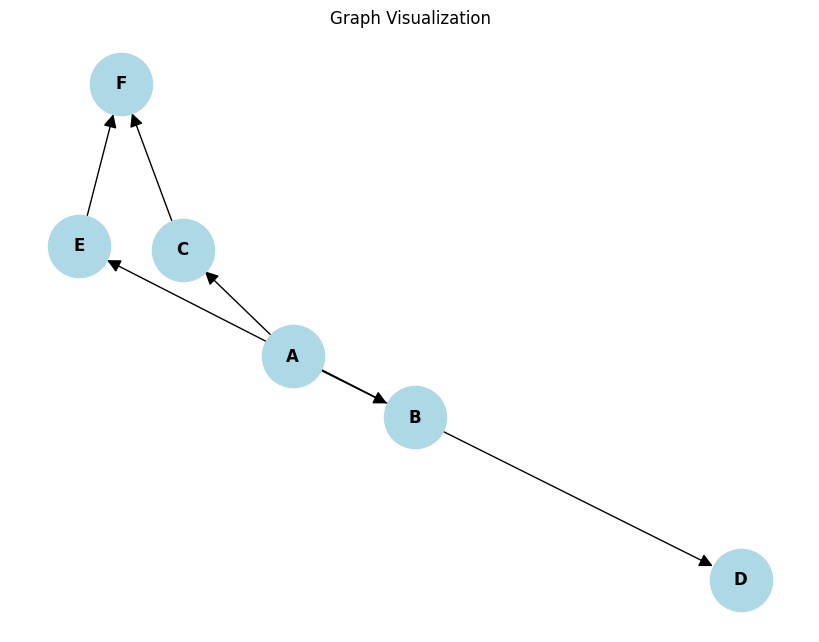

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a NetworkX graph from your Graph class's adjacency list
G_nx = nx.DiGraph() # Use DiGraph for directed graph (as per add_edge implementation)

for node, neighbors in g.graph.items():
    for neighbor in neighbors:
        G_nx.add_edge(node, neighbor)

# Draw the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_nx) # You can choose different layouts (e.g., circular_layout, shell_layout)
nx.draw(G_nx, pos, with_labels=True, node_size=2000, node_color='lightblue', font_size=12, font_weight='bold', arrowsize=20)
plt.title("Graph Visualization")
plt.show()

### Alternative BFS and DFS Implementation

This implementation uses a standard dictionary for the adjacency list and provides another example of BFS and DFS traversals.

In [6]:
from collections import deque

class AltGraph:
    def __init__(self, adj_list=None):
        self.graph = adj_list if adj_list is not None else {}

    def add_node(self, node):
        if node not in self.graph:
            self.graph[node] = []

    def add_edge(self, u, v):
        self.add_node(u) # Ensure node u exists
        self.add_node(v) # Ensure node v exists
        self.graph[u].append(v)
        # For an undirected graph, uncomment the line below
        # self.graph[v].append(u)

    def bfs(self, start_node):
        if start_node not in self.graph:
            return []

        visited = set()
        queue = deque([start_node])
        traversal_order = []

        visited.add(start_node)

        while queue:
            node = queue.popleft()
            traversal_order.append(node)

            for neighbor in self.graph.get(node, []):
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append(neighbor)
        return traversal_order

    def dfs(self, start_node):
        if start_node not in self.graph:
            return []

        visited = set()
        traversal_order = []

        def dfs_recursive(node):
            visited.add(node)
            traversal_order.append(node)

            for neighbor in self.graph.get(node, []):
                if neighbor not in visited:
                    dfs_recursive(neighbor)

        dfs_recursive(start_node)
        return traversal_order

# Create a new sample graph
alt_g = AltGraph()
alt_g.add_edge(0, 1)
alt_g.add_edge(0, 2)
alt_g.add_edge(1, 3)
alt_g.add_edge(1, 4)
alt_g.add_edge(2, 5)
alt_g.add_edge(3, 6)

print("Alternative Graph representation:", alt_g.graph)


Alternative Graph representation: {0: [1, 2], 1: [3, 4], 2: [5], 3: [6], 4: [], 5: [], 6: []}


In [7]:
# Perform BFS on the alternative graph starting from node 0
alt_bfs_traversal = alt_g.bfs(0)
print("Alternative BFS Traversal (starting from 0):", alt_bfs_traversal)

Alternative BFS Traversal (starting from 0): [0, 1, 2, 3, 4, 5, 6]


In [8]:
# Perform DFS on the alternative graph starting from node 0
alt_dfs_traversal = alt_g.dfs(0)
print("Alternative DFS Traversal (starting from 0):", alt_dfs_traversal)

Alternative DFS Traversal (starting from 0): [0, 1, 3, 6, 4, 2, 5]


### Simple Graph Representation

We'll use a dictionary to represent our graph, where each key is a node and its value is a list of its neighbors.

In [9]:
# Define a simple graph using an adjacency list (dictionary)
graph_simple = {
    'A': ['B', 'C'],
    'B': ['D', ],
    'C': ['E'],
    'D': ['F'],
    'E': [],
    'F': []
}

print("Simple Graph:", graph_simple)

Simple Graph: {'A': ['B', 'C'], 'B': ['D'], 'C': ['E'], 'D': ['F'], 'E': [], 'F': []}


### Simple Breadth-First Search (BFS)

Here's a basic BFS implementation for the graph defined above.

In [10]:
from collections import deque

def bfs_simple(graph, start_node):
    visited = set()
    queue = deque([start_node])
    traversal = []

    visited.add(start_node)

    while queue:
        current_node = queue.popleft()
        traversal.append(current_node)

        for neighbor in graph.get(current_node, []):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
    return traversal

# Perform BFS starting from 'A'
bfs_result = bfs_simple(graph_simple, 'A')
print("BFS Traversal (from A):", bfs_result)

BFS Traversal (from A): ['A', 'B', 'C', 'D', 'E', 'F']


### Simple Depth-First Search (DFS)

And here's a basic DFS implementation for the same graph.

In [11]:
def dfs_simple(graph, start_node):
    visited = set()
    traversal = []

    def dfs_recursive(node):
        visited.add(node)
        traversal.append(node)

        for neighbor in graph.get(node, []):
            if neighbor not in visited:
                dfs_recursive(neighbor)

    dfs_recursive(start_node)
    return traversal

# Perform DFS starting from 'A'
dfs_result = dfs_simple(graph_simple, 'A')
print("DFS Traversal (from A):", dfs_result)

DFS Traversal (from A): ['A', 'B', 'D', 'F', 'C', 'E']
